<a href="https://colab.research.google.com/github/anvi-rohra19/Data-Analyst-Portfolio/blob/main/Yulu_BusinessCase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Yulu** is an Indian shared electric mobility company that provides eco-friendly e-bikes for short-distance commuting and deliveries. Founded in 2017, Yulu operates app-based electric vehicles mainly for last-mile transport, helping reduce traffic congestion and pollution in cities.

**Problem Statement:**
The company wants to know:

* Which variables are significant in predicting the demand for shared electric
cycles in the Indian market?
* How well those variables describe the electric cycle demands

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import f_oneway
from scipy.stats import kruskal
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("bike_sharing.csv")
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
df.shape

(10886, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [ ]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [ ]:
def dist_check(df, col_name):
  print("Unique values : ", df[col_name].unique())
  print("Value counts : ")
  print(df[col_name].value_counts())

In [ ]:
col_list = ['workingday',	'holiday',	'weather', 'season']

In [ ]:
for items in col_list:
  print(f"Column Name: {items}")
  dist_check(df, col_name = items)
  print("----"* 20)

Column Name: workingday
Unique values :  [0 1]
Value counts : 
workingday
1    7412
0    3474
Name: count, dtype: int64
--------------------------------------------------------------------------------
Column Name: holiday
Unique values :  [0 1]
Value counts : 
holiday
0    10575
1      311
Name: count, dtype: int64
--------------------------------------------------------------------------------
Column Name: weather
Unique values :  [1 2 3 4]
Value counts : 
weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64
--------------------------------------------------------------------------------
Column Name: season
Unique values :  [1 2 3 4]
Value counts : 
season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64
--------------------------------------------------------------------------------


In [ ]:
df_only_num = df.select_dtypes(include = ["float","int"])

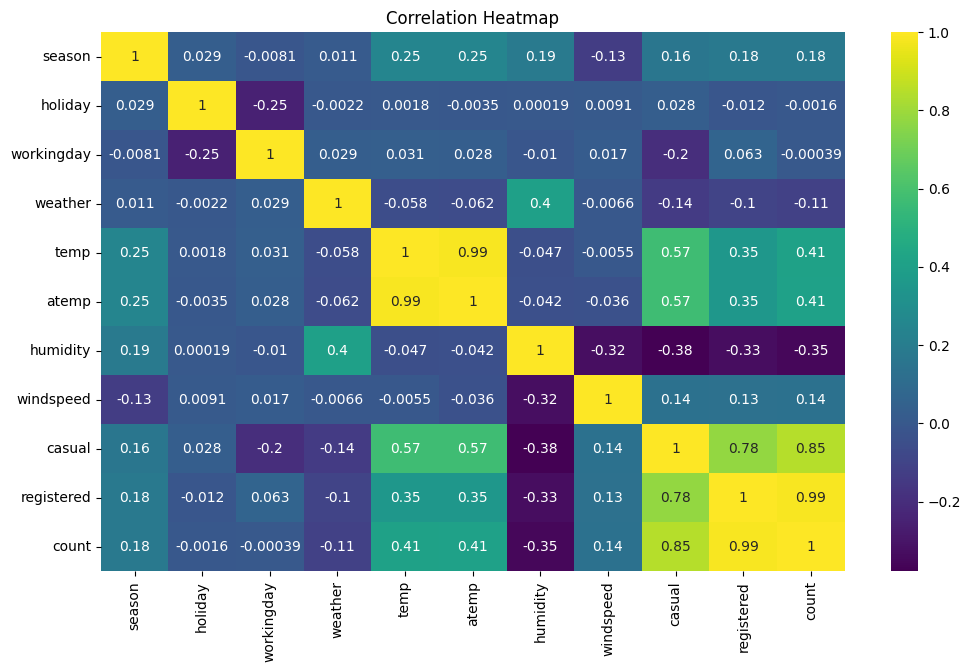

In [ ]:
plt.figure(figsize=(12, 7))
sns.heatmap(df_only_num.corr(method='spearman'),
            annot=True, cmap='viridis')
plt.title("Correlation Heatmap")
plt.show()

# **Observations:**

1. The dataset contains 10,886 records and 12 columns.
2. None of the column has a null value (NaN values), hence no missing values.
3. Statistical Summary:
* Registered users(mean ≈ 155) dominate rentals compared to casual users(mean ≈ 36).
* 68% are working days → weekday commuting drives most usage.
* Holidays represent only ~3% of records → small but important segment.
* Majority Weather (66%) falls under good weather conditions (category 1), Only 1 entry for category 4 → can be considered an outlier.
* Seasons are almost equally represented → no seasonal imbalance.
4. Heatmap:
* Temperature (temp & atemp) shows a very strong positive correlation (~0.99), indicating they capture almost the same information.
* Registered users have the strongest correlation with total count (~0.99), meaning registered riders drive overall rental demand.
* Casual users also show strong correlation with count (~0.85), but less compared to registered users.
* Temperature positively impacts both casual and registered rentals, especially casual users (~0.57).
* Humidity has a negative correlation with rental counts (around -0.33 to -0.38), suggesting fewer rides in humid conditions.
* Windspeed shows weak correlation with demand, indicating minimal influence on rentals.
* Holiday, workingday, and season have very weak correlations with rental count, meaning their relationship with demand may be non-linear.
* Weather and humidity show moderate correlation (~0.40), which is expected as poor weather often brings higher humidity.
* Overall, No strong similarity between most variables except temp and atemp, which suggests one of them can be dropped.


In [ ]:
# Dropping highly correlated columns
dfn = df.drop(columns=['atemp'])
dfn.head()

,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,75,0.0,0,1,1


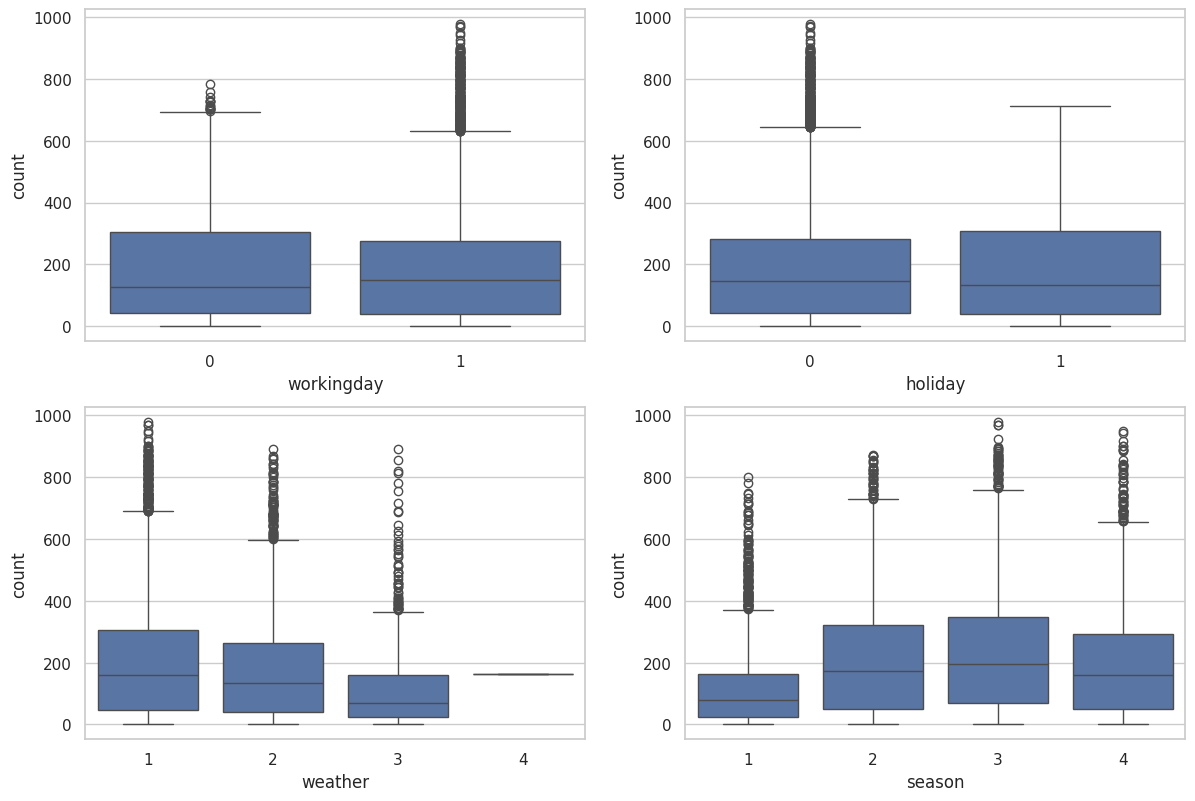

In [ ]:
# Outlier Detection using Boxplots -

sns.set(style="whitegrid")
fig = plt.figure(figsize=(8, 25))
fig.subplots_adjust(right=1.5)

for plot in range(1, len(col_list)+1):
    plt.subplot(5, 2, plot)
    sns.boxplot(x=dfn[col_list[plot-1]], y=dfn['count'])

plt.show()

**The data is right skewed.**

## **Problem Statement 1:  Is there any significant difference between the no. of bike rides on weekdays and weekends?**

### Hypothesis Testing with 2 Sample T test - test of independence
H0:  The demand of bikes on weekdays is greater or similar to the demand of bikes on weekend.

Ha:  The demand of bikes on weekdays is less than the demand of bikes on weekend.

In [ ]:
pd.DataFrame(dfn.groupby('workingday')['count'].describe())

,count,mean,std,min,25%,50%,75%,max
workingday,,,,,,,,
0,3474.0,188.506621,173.724015,1.0,44.0,128.0,304.0,783.0
1,7412.0,193.011873,184.513659,1.0,41.0,151.0,277.0,977.0


In [ ]:
weekday = dfn[dfn['workingday'] == 1]['count'].sample(3000)
weekend = dfn[dfn['workingday'] == 0]['count'].sample(3000)

In [ ]:
print('The sample standard deviation of the bike rides on weekday is:', round(weekday.std(), 2))
print('The sample standard deviation of the bike rides on weekend is:', round(weekend.std(), 2))

The sample standard deviation of the bike rides on weekday is: 180.48
The sample standard deviation of the bike rides on weekend is: 174.67


In [ ]:
alpha = 0.05

In [ ]:
def result(p_value, alpha):
  if p_value < alpha:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
  else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

In [ ]:
test_stat, p_value = ttest_ind(weekday, weekend, equal_var=False, alternative='less')
print('The p-value is : ', p_value)

result(p_value, alpha)

The p-value is :  0.6555061260881289
As the p-value 0.6555061260881289 is greater than the level of significance, we fail to reject the null hypothesis.


## **Problem Statement 2: Are weather conditions significantly different during different seasons?**

### Hypothesis Testing with ChiSquare Test
H0:  Weather conditions are independent of the season.

Ha:  Weather condition depends on the ongoing season.

In [ ]:
dict1 = {1: 'Sunny',
         2: 'Cloudy',
         3: 'Rainy'}
dfn['weather_enc'] = dfn['weather'].map(dict1)

In [ ]:
dict2 = {1: 'Summer',
         2: 'Monsoon',
         3: 'Winter',
         4: 'Autumn'}
dfn['season_enc'] = dfn['season'].map(dict2)

In [ ]:
contigency= pd.crosstab(dfn.season_enc, dfn.weather_enc)
contigency

weather_enc,Cloudy,Rainy,Sunny
season_enc,,,
Autumn,807,225,1702
Monsoon,708,224,1801
Summer,715,211,1759
Winter,604,199,1930


In [ ]:
chi2, pval, dof, exp_freq = chi2_contingency(contigency, correction=False)
print('Chi-square Statistic: {} \n P-value: {} \n Degree of Freedom: {} \n Expected Frequencies: {}'.format(chi2, pval, dof, exp_freq))

Chi-square Statistic: 46.10145731073249 
 P-value: 2.8260014509929343e-08 
 Degree of Freedom: 6 
 Expected Frequencies: [[ 711.81956821  215.75617823 1806.42425356]
 [ 711.55920992  215.67726229 1805.76352779]
 [ 699.06201194  211.8892972  1774.04869086]
 [ 711.55920992  215.67726229 1805.76352779]]


In [ ]:
result(pval, alpha)

As the p-value 2.8260014509929343e-08 is less than the level of significance, we reject the null hypothesis.


## **Problem Statement 3: Is the demand of bicycles on rent same for different weather conditions?**

### Hypothesis Testing with ANOVA test

H0:  The average no. of bike rides in different weather conditions are equal.

Ha:  The average no. of bike rides in different weather conditions are not equal.

In [ ]:
dfn = dfn[~(dfn['weather']==4)] #removing rows where weather equals 4

In [ ]:
w1 = dfn[dfn['weather'] == 1]['count'].sample(750)
w2 = dfn[dfn['weather'] == 2]['count'].sample(750)
w3 = dfn[dfn['weather'] == 3]['count'].sample(750)

The ANOVA test has important assumptions that must be satisfied in order for the associated p-value to be valid.

* The samples are independent.
* Each sample is from a normally distributed population.
* The population variance of the groups are all equal.

We will be using the following statistical tests to check the normality and euality of variance of the data set -

* For testing of normality, Shapiro-Wilk’s test is applied to the response variable.
* For equality of variance, Levene test is applied to the response variable.

### Shapiro-Wilk's Test - to check normality

HO: Count follows normal distribution

Ha: Count doesn't follow normal distribution

In [ ]:
w, p_value = shapiro(dfn['count'].sample(4999))
print('The p-value is : ', p_value)

result(p_value, alpha)

The p-value is :  9.31659236012731e-52
As the p-value 9.31659236012731e-52 is less than the level of significance, we reject the null hypothesis.


### Levene’s test - to check variances

H0 : All the count variances are equal

Ha : At least one variance is different from the rest

In [ ]:
stat, p_value = levene(w1, w2, w3)
print('The p-value is : ', p_value)

result(p_value, alpha)

The p-value is :  1.371199522616919e-16
As the p-value 1.371199522616919e-16 is less than the level of significance, we reject the null hypothesis.


Note: Since we are using ANOVA and the results for Levene's Test and Normality test failed, this result may not be accuarte.

In [ ]:
test_stat, p_value = f_oneway(w1, w2, w3)
print('The p-value is : ', p_value)

result(p_value, alpha)

The p-value is :  3.051203993709381e-23
As the p-value 3.051203993709381e-23 is less than the level of significance, we reject the null hypothesis.


### Kruskal Wallis test - non parametric test (Alternate for ANOVA)

In [ ]:
stat, p_value = kruskal(w1, w2, w3)
print('The p-value is : ', p_value)

result(p_value, alpha)

The p-value is :  6.861087033339547e-25
As the p-value 6.861087033339547e-25 is less than the level of significance, we reject the null hypothesis.


Hence, The average no. of bike rides in different weather conditions are not equal.

## **Problem Statement 4:  Is there a significant difference in bike rentals between regular days and holidays?**

### Hypothesis Testing with 2 Sample T test - test of independence
H0:  The demand of bikes on regular days has no significant difference to the demand of bikes on holidays.

Ha:  The demand of bikes on regular days is greater than the demand of bikes on holidays.

In [ ]:
pd.DataFrame(dfn.groupby('holiday')['count'].describe())

,count,mean,std,min,25%,50%,75%,max
holiday,,,,,,,,
0,10574.0,191.744278,181.521514,1.0,43.0,145.0,283.0,977.0
1,311.0,185.877814,168.300531,1.0,38.5,133.0,308.0,712.0


In [ ]:
holiday = dfn[dfn['holiday'] == 1]['count']
regular_day = dfn[dfn['holiday'] == 0]['count']

In [ ]:
print('The sample standard deviation of the bike rental on holiday is:', round(holiday.std(), 2))
print('The sample standard deviation of the bike rental on regular_day is:', round(regular_day.std(), 2))

The sample standard deviation of the bike rental on holiday is: 168.3
The sample standard deviation of the bike rental on regular_day is: 181.52


In [ ]:
test_stat, p_value = ttest_ind(holiday, regular_day, equal_var=False, alternative='greater')
print('The p-value is : ', p_value)

result(p_value, alpha)

The p-value is :  0.727023621621516
As the p-value 0.727023621621516 is greater than the level of significance, we fail to reject the null hypothesis.


## **Problem Statement 5:  Determine whether bicycle rental demand varies across different seasons.**

### Hypothesis Testing with One way ANOVA test
H0:  There is no significant difference in demand across seasons.

Ha:  There is a significant difference in demand across seasons.

In [ ]:
pd.DataFrame(dfn.groupby('season')['count'].describe())

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2685.0,116.325512,125.293931,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


In [ ]:
s1 = dfn[dfn['season'] == 1]['count'].sample(2500)
s2 = dfn[dfn['season'] == 2]['count'].sample(2500)
s3 = dfn[dfn['season'] == 3]['count'].sample(2500)
s4 = dfn[dfn['season'] == 3]['count'].sample(2500)

Since we already know that the distribution of count is not normal, we will be performing Levene's test to check variances.

### Levene’s test - to check variances

H0 : All the count variances are equal

Ha : At least one variance is different from the rest

In [ ]:
stat, p_value = levene(s1, s2, s3,s4)
print('The p-value is : ', p_value)

result(p_value, alpha)

The p-value is :  1.1515798755868985e-119
As the p-value 1.1515798755868985e-119 is less than the level of significance, we reject the null hypothesis.


Note: Since we are using ANOVA and the results for Levene's Test and Normality test failed, this result may not be accuarte.

In [ ]:
test_stat, p_value = f_oneway(s1, s2, s3, s4)
print('The p-value is : ', p_value)

result(p_value, alpha)

The p-value is :  7.285541555867916e-154
As the p-value 7.285541555867916e-154 is less than the level of significance, we reject the null hypothesis.


### Kruskal Wallis test - non parametric test (Alternate for ANOVA)

In [ ]:
stat, p_value = kruskal(s1, s2, s3, s4)
print('The p-value is : ', p_value)

result(p_value, alpha)

The p-value is :  1.063840411935317e-161
As the p-value 1.063840411935317e-161 is less than the level of significance, we reject the null hypothesis.


Hence, There is a significant difference in demand across seasons.

# **Observations**

1. Day type (weekday vs weekend) does not significantly impact bike rental demand.

2. Weather conditions are strongly influenced by seasons, confirming expected climatic patterns.

3. Bike rental demand varies significantly across different weather conditions.

4. Holidays do not significantly change rental demand compared to regular days.

5. Seasonality plays a major role in bike rental demand, with clear differences across seasons.

# **Recommendations**

1. Maintain consistent fleet availability across weekdays and weekends.
Avoid weekend-only promotions; focus instead on time-of-day or weather-based offers.
2. Align maintenance schedules and fleet allocation with seasonal weather trends.
3. Reduce fleet exposure during poor weather to control operational costs.
Push app notifications encouraging rides during favorable weather windows.
4. Do not design holiday-only campaigns. Focus instead on seasonal and weather-driven demand patterns.
5. Schedule major maintenance during low-demand seasons.
Adjust pricing and subscription plans seasonally.